In [1]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('src')

random.seed(42)
np.random.seed(42)

In [2]:
from constructive import ConstructiveNumber
from functions import rastrigin, ackley, desmos_func
from stochastic_optimizers import simulated_annealing, differential_evolution

## Стохастические методы на тестовых функциях

In [3]:
funcs = [
    ('rastrigin_2d', rastrigin, [(-5,5),(-5,5)], np.array([2.0, 2.0])),
    ('ackley',       ackley,    [(-5,5),(-5,5)], np.array([2.0, 2.0])),
    ('desmos',       desmos_func, [(-5,5),(-5,5),(-5,5)], np.array([1.0,1.0,1.0])),
]

results = {}
for name, f, bounds, x0 in funcs:
    sa = simulated_annealing(f, x0, T0=10, alpha=0.97)
    de = differential_evolution(f, bounds, max_iter=300)
    results[name] = {'sa': sa, 'de': de}
    print(f'\n=== {name} ===')
    print(f'  SA: f={sa["f"]:.6f}, iters={sa["iters"]}, f_calls={sa["f_calls"]}')
    print(f'  DE: f={de["f"]:.6f}, iters={de["iters"]}, f_calls={de["f_calls"]}')


=== rastrigin_2d ===
  SA: f=8.000000, iters=454, f_calls=455
  DE: f=0.000000, iters=301, f_calls=6020

=== ackley ===
  SA: f=3.577061, iters=454, f_calls=455
  DE: f=0.000000, iters=301, f_calls=6020



=== desmos ===
  SA: f=-0.994056, iters=454, f_calls=455
  DE: f=-1.000000, iters=301, f_calls=6020


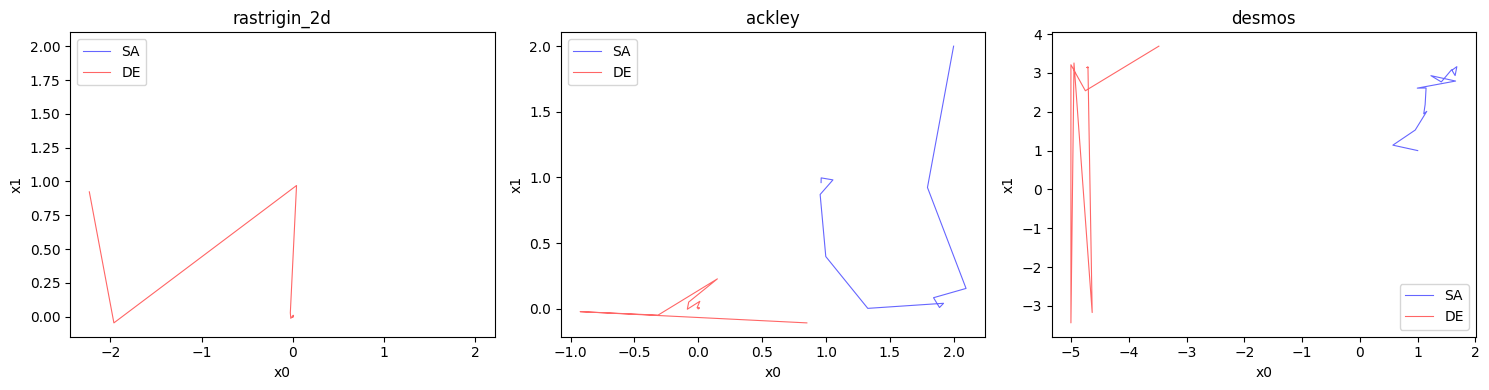

In [4]:
# Траектории (x0 vs x1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, f, bounds, x0) in zip(axes, funcs):
    sa_hist = np.array(results[name]['sa']['history'])
    de_hist = np.array(results[name]['de']['history'])

    ax.plot(sa_hist[:, 0], sa_hist[:, 1], 'b-', alpha=0.6, linewidth=0.8, label='SA')
    ax.plot(de_hist[:, 0], de_hist[:, 1], 'r-', alpha=0.6, linewidth=0.8, label='DE')
    ax.set_title(name)
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    ax.legend()

plt.tight_layout()
plt.savefig('trajectory.png', dpi=100)
plt.show()

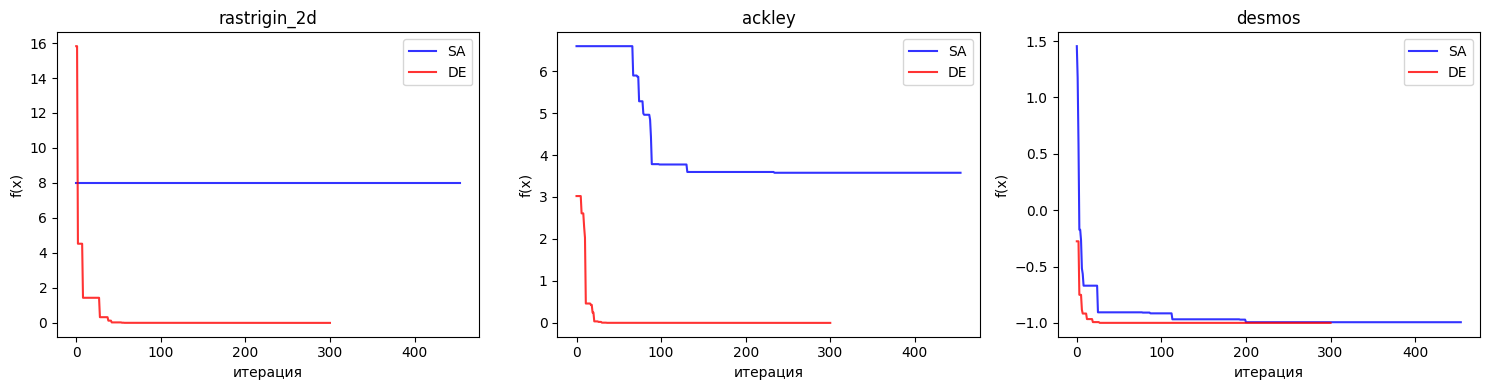

In [5]:
# Сходимость f(x) по итерациям
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, f, bounds, x0) in zip(axes, funcs):
    sa_hist = np.array(results[name]['sa']['history'])
    de_hist = np.array(results[name]['de']['history'])

    sa_fvals = [float(f(x)) if not isinstance(f(x), ConstructiveNumber) else f(x).get(0.5) for x in sa_hist]
    de_fvals = [float(f(x)) if not isinstance(f(x), ConstructiveNumber) else f(x).get(0.5) for x in de_hist]

    ax.plot(sa_fvals, 'b-', alpha=0.8, label='SA')
    ax.plot(de_fvals, 'r-', alpha=0.8, label='DE')
    ax.set_title(name)
    ax.set_xlabel('итерация')
    ax.set_ylabel('f(x)')
    ax.legend()

plt.tight_layout()
plt.savefig('convergence.png', dpi=100)
plt.show()

## Сравнение с методами лабы 1

In [6]:
# На Растригине GD и NM из лаб 1 застревают в локальных минимумах
# Здесь сравниваем SA и DE с ними

# Простой GD для сравнения
def simple_gd(f, x0, lr=0.01, max_iter=5000, tol=1e-6):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    f_calls = 0
    eps = 1e-5
    for _ in range(max_iter):
        grad = np.zeros_like(x)
        for i in range(len(x)):
            xp, xm = x.copy(), x.copy()
            xp[i] += eps; xm[i] -= eps
            fp = float(f(xp)) if not isinstance(f(xp), ConstructiveNumber) else f(xp).get(0.5)
            fm = float(f(xm)) if not isinstance(f(xm), ConstructiveNumber) else f(xm).get(0.5)
            grad[i] = (fp - fm) / (2 * eps)
            f_calls += 2
        if np.linalg.norm(grad) < tol:
            break
        x = x - lr * grad
        history.append(x.copy())
    fval = float(f(x)) if not isinstance(f(x), ConstructiveNumber) else f(x).get(0.5)
    f_calls += 1
    return {'x': x, 'f': fval, 'history': history, 'f_calls': f_calls, 'iters': len(history)-1}

x0_2d = np.array([2.0, 2.0])
np.random.seed(42)
gd_r  = simple_gd(rastrigin, x0_2d, lr=0.01)
sa_r  = simulated_annealing(rastrigin, x0_2d, T0=10, alpha=0.97)
de_r  = differential_evolution(rastrigin, [(-5,5),(-5,5)], max_iter=300)

print(f'{'Метод':<6} {'f_min':<12} {'iters':<8} {'f_calls'}')
print('-' * 40)
for name, res in [('GD', gd_r), ('SA', sa_r), ('DE', de_r)]:
    print(f'{name:<6} {res["f"]:<12.6f} {res["iters"]:<8} {res["f_calls"]}')

Метод  f_min        iters    f_calls
----------------------------------------
GD     44.156258    5000     20001
SA     8.000000     454      455
DE     0.000000     301      6020


In [7]:
# Итоговая сводная таблица
print(f'{'Функция':<14} {'Метод':<5} {'f_min':<12} {'iters':<8} {'f_calls':<10} {'mem (est.)'}')
print('-' * 60)
for name in results:
    for mname, res in [('SA', results[name]['sa']), ('DE', results[name]['de'])]:
        # memory estimate: SA stores 1 point per iter, DE stores pop_size * n
        mem = f'{len(res["history"])} pts'
        print(f'{name:<14} {mname:<5} {res["f"]:<12.6f} {res["iters"]:<8} {res["f_calls"]:<10} {mem}')

Функция        Метод f_min        iters    f_calls    mem (est.)
------------------------------------------------------------
rastrigin_2d   SA    8.000000     454      455        455 pts
rastrigin_2d   DE    0.000000     301      6020       301 pts
ackley         SA    3.577061     454      455        455 pts
ackley         DE    0.000000     301      6020       301 pts
desmos         SA    -0.994056    454      455        455 pts
desmos         DE    -1.000000    301      6020       301 pts
